# AG News Text Classification with Classical Machine Learning

**Big Data Analytics and Text Mining — Module 2** · University of Bologna (Prof. Stefano Lodi)

**Author:** Kawsar Farooq (kawsarfarooq@gmail.com)
**Date:** July 2026

---

## Abstract

This project studies large-scale multi-class text classification on the **AG News** corpus
(127,600 news articles, 4 balanced classes: *World*, *Sports*, *Business*, *Sci/Tech*).

The articles are represented using sublinear TF-IDF features over word unigrams and
bigrams, producing a high-dimensional sparse feature space of about 200,000 features.
Three classical machine-learning algorithms are compared: **Multinomial Naive Bayes**,
**Logistic Regression**, and a **Linear SVM**.

Hyperparameters (n-gram range, Naive Bayes smoothing α, and regularization C) are selected
using a stratified validation split from the training data, while the official test set is
kept separate from model selection. The best-performing model is the Linear SVM, reaching
about 92.8% test accuracy and 0.928 macro-F1.

The main remaining errors occur between *Business* and *Sci/Tech*, which share vocabulary
around companies, markets, and technology.

## Course requirement check

| Requirement | This project |
|---|---|
| N ≥ 20,000 | **N = 127,600** (120,000 train + 7,600 test) |
| p ≥ 4 | **p ≈ 200,000** TF-IDF features (the raw table also has 7 columns after feature derivation) |
| n_A ≥ 3 | **3 algorithms:** Multinomial Naive Bayes, Logistic Regression, Linear SVM |
| N·p ≥ 1,000,000 | 127,600 × 200,000 ≈ **2.5 × 10¹⁰** |

**Dataset:** AG News — https://huggingface.co/datasets/sh0416/ag_news

<a id="toc"></a>
## Table of contents

- [Requirements & setup](#setup)
- [Methodology](#methodology)
- [1. Data loading](#data-loading)
  - [1.1 Derived raw features](#derived-features)
- [2. Exploratory data analysis](#eda)
- [3. Feature extraction (TF-IDF)](#feature-extraction)
- [4. Baseline models](#baselines)
- [5. Hyperparameter tuning](#tuning)
- [6. Final evaluation on the test set](#final-eval)
- [7. Discussion of results](#discussion)
- [8. Conclusion](#conclusion)
- [References](#references)

<a id="setup"></a>
## Requirements & Setup

### Required library versions

This notebook was developed and tested with the following environment.

| Library | Version |
|---|---|
| python | 3.12 |
| numpy | ≥ 1.24 |
| pandas | 3.0 |
| scikit-learn | 1.9 |
| matplotlib | 3.11 |
| seaborn | 0.13 |
| datasets | ≥ 2.14 |


### How to run

From the project root:

```bash
# Create and activate a virtual environment
python -m venv .venv
# Windows:  .\.venv\Scripts\Activate.ps1
# Linux/macOS:  source .venv/bin/activate

# Install dependencies
pip install -r requirements.txt

# Launch and run all cells
jupyter notebook ag_news_classification.ipynb
```

<a id="methodology"></a>
## Methodology

The experimental pipeline follows a standard, leakage-safe supervised-learning protocol:

1. **Data acquisition.** The AG News dataset is downloaded directly in the notebook. The Hugging Face version is used as the main source, with a GitHub CSV version as a fallback. The original train/test split (120,000 / 7,600) is kept unchanged.
2. **Preprocessing.** The title and description columns are combined into a single text field. The text is then converted into TF-IDF features using word unigrams and bigrams, English stop-word removal, a minimum document frequency of 2, and a maximum of 200,000 features. The vectorizer is fitted only on the training data and then applied to the test data.
3. **Models.** Three classical linear/probabilistic classifiers are compared:
   Multinomial Naive Bayes, Logistic Regression (multinomial, `lbfgs`), and a
   Linear Support Vector Machine (`LinearSVC`). These models were selected because they are widely used and effective for text classification tasks.
4. **Model selection.** Hyperparameter tuning is performed using a stratified 10% validation split from the training set. The tuned parameters include the TF-IDF n-gram range, the Naive Bayes smoothing coefficient α, and the regularization strength C for Logistic Regression and Linear SVM. The official test set is kept separate during this process and is used only for the final model evaluation.
5. **Evaluation.** The models are evaluated using accuracy and macro F1-score. Per-class precision, recall, F1-score, and confusion matrices are also used to better understand the classification errors.

**Reproducibility.** A fixed random seed (`RANDOM_STATE = 42`)  is used for all random steps, including the validation split and the SVM solver.

In [1]:
# --- Imports and global configuration ---
import sys
import time

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

# Print the runtime versions so the environment is documented in the output itself.
print("python      :", sys.version.split()[0])
print("numpy       :", np.__version__)
print("pandas      :", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib  :", matplotlib.__version__)
print("seaborn     :", sns.__version__)

# Single seed used for every stochastic step (validation split, SVM solver) so the
# whole notebook is reproducible from a clean "Run All".
RANDOM_STATE = 42

# Consistent plot styling throughout the notebook.
sns.set_theme(style="whitegrid")

python      : 3.12.10
numpy       : 2.5.1
pandas      : 3.0.3
scikit-learn: 1.9.0
matplotlib  : 3.11.0
seaborn     : 0.13.2


<a id="data"></a>
## 1. Dataset

The AG News dataset is loaded directly in the notebook, so no separate data files are required in the repository. The notebook first uses the Hugging Face dataset source (sh0416/ag_news).

The original dataset contains 127,600 articles and three fields: label, title, and description. Additional columns are created later for exploratory analysis and model development

*[back to top](#toc)*

In [ ]:
COLS = ["label", "title", "description"]
CLASS_NAMES = {1: "World", 2: "Sports", 3: "Business", 4: "Sci/Tech"}


def load_agnews():
    """Download the AG News dataset and return it as two DataFrames.

    1. The HuggingFace hub dataset ``sh0416/ag_news``
    2. If the ``datasets`` library is missing or the hub is unreachable, the GitHub CSV
       mirror of the identical corpus is used as an automatic fallback.
    """
    try:
        from datasets import load_dataset
        ds = load_dataset("sh0416/ag_news")
        tr = ds["train"].to_pandas()[COLS]
        te = ds["test"].to_pandas()[COLS]
        print("Loaded from HuggingFace: sh0416/ag_news")
        return tr, te
    except Exception as e:
        # Any failure (library absent, offline, hub error) falls through to the mirror.
        print(f"HuggingFace path unavailable ({type(e).__name__}); falling back to GitHub mirror.")

    # --- Fallback source: GitHub mirror of the identical corpus ---
    base = "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv"
    tr = pd.read_csv(f"{base}/train.csv", header=None, names=COLS)
    te = pd.read_csv(f"{base}/test.csv", header=None, names=COLS)
    print("Loaded from GitHub mirror.")
    return tr, te


train_df, test_df = load_agnews()
print("Train:", train_df.shape, "| Test:", test_df.shape, "| N =", len(train_df) + len(test_df))
train_df.head(3)

Loaded from HuggingFace: sh0416/ag_news
Train: (120000, 3) | Test: (7600, 3) | N = 127600


,label,title,description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...


<a id="Additional Features"></a>
### 1.1 Additional Features
Three additional columns are created from the original data: (`title_len_words`, `desc_len_words`) and `text`. The first two record the number of words in the title and description and are used in the exploratory analysis. The text column combines the title and description and is later used for TF-IDF vectorization. These columns also ensure that the dataset meets the requirement of having at least four features.

In [3]:
# Build the derived columns on both splits with identical logic.
for df in (train_df, test_df):
    # Concatenate title + description into the single field used for vectorization.
    df["text"] = df["title"].str.strip() + " " + df["description"].str.strip()
    # Simple length features (word counts) used in the exploratory analysis.
    df["title_len_words"] = df["title"].str.split().str.len()
    df["desc_len_words"] = df["description"].str.split().str.len()
    # Human-readable class label for plots and grouping.
    df["class_name"] = df["label"].map(CLASS_NAMES)

# Sanity check: no missing values should have been introduced by the joins/maps.
assert train_df[["text", "class_name"]].notna().all().all(), "Unexpected missing values after feature derivation"

print("Raw columns now:", list(train_df.columns))
train_df.head(3)

Raw columns now: ['label', 'title', 'description', 'text', 'title_len_words', 'desc_len_words', 'class_name']


,label,title,description,text,title_len_words,desc_len_words,class_name
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Wall St. Bears Claw Back Into the Black (Reute...,9,12,Business
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...,6,30,Business
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Oil and Economy Cloud Stocks' Outlook (Reuters...,7,29,Business


<a id="eda"></a>
## 2. Data Analysis

This section examines the overall dataset and each news category separately. The analysis includes class distribution, document-length statistics, and the most common or distinctive words in each class. The aim is to understand the dataset structure and identify any patterns that may affect model performance.

*[back to top](#toc)*

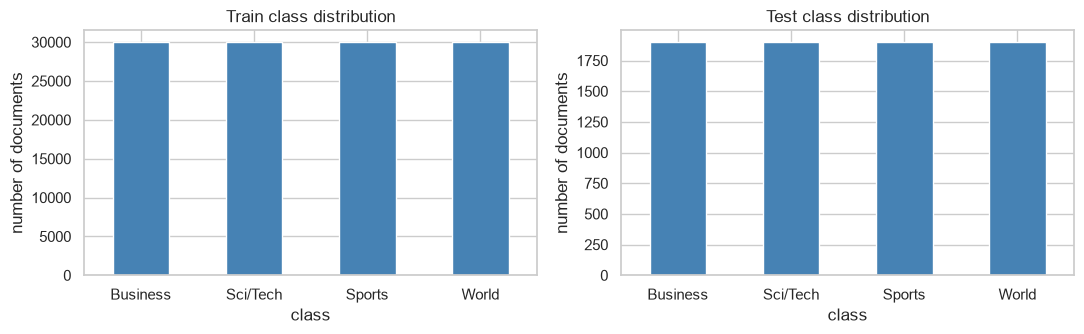

class_name
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64


In [ ]:
# Class distribution in the train and test splits.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, df, name in zip(axes, (train_df, test_df), ("Train", "Test")):
    (df["class_name"].value_counts()
                     .sort_index()
                     .plot(kind="bar", ax=ax, color="steelblue"))
    ax.set_title(f"{name} class distribution")
    ax.set_xlabel("class")
    ax.set_ylabel("Number of documents")
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

print(train_df["class_name"].value_counts())

title_len_words               desc_len_words                
                      mean   std min max           mean    std min  max
class_name                                                             
Business              6.80  2.01   1  19          30.74   7.78   4  131
Sci/Tech              6.66  1.92   1  18          30.53  12.21   3  173
Sports                6.43  2.21   1  17          31.35   8.57   6  149
World                 7.25  2.11   1  17          31.63   9.85   6  139

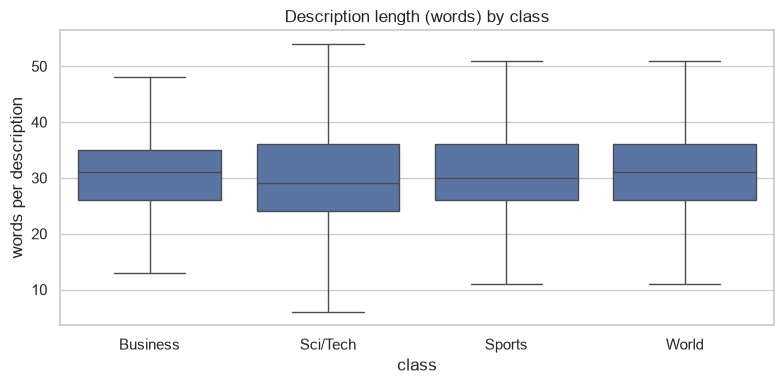

In [ ]:
# Document-length statistics, overall and by class.
len_stats = (train_df
             .groupby("class_name")[["title_len_words", "desc_len_words"]]
             .agg(["mean", "std", "min", "max"])
             .round(2))
display(len_stats)

# Distribution of description length per class (outliers hidden for readability).
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=train_df, x="class_name", y="desc_len_words", showfliers=False, ax=ax)
ax.set_title("Description Length (words) by Class")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Words")
plt.tight_layout()
plt.show()

In [ ]:
# Most characteristic terms per class, ranked by mean TF-IDF weight within the class.
# A separate lightweight vectorizer is used here (capped at 30k features, unigrams only)
# purely for interpretable EDA; it is independent of the modelling vectorizer built later.
from sklearn.feature_extraction.text import TfidfVectorizer

eda_vec = TfidfVectorizer(stop_words="english", max_features=30000, sublinear_tf=True)
X_eda = eda_vec.fit_transform(train_df["text"])
vocab = np.array(eda_vec.get_feature_names_out())

top_terms = {}
for lbl, name in CLASS_NAMES.items():
    mask = (train_df["label"] == lbl).to_numpy()          # rows belonging to this class
    mean_w = np.asarray(X_eda[mask].mean(axis=0)).ravel()  # mean TF-IDF of each term
    top_terms[name] = vocab[mean_w.argsort()[::-1][:12]]   # 12 highest-weighted terms
pd.DataFrame(top_terms)

**Key Observations.**
The dataset is perfectly balanced, with 30,000 training samples and 1,900 test samples in each class. Therefore, accuracy is an appropriate evaluation metric. Titles contain approximately seven words on average, while descriptions generally contain between 26 and 32 words. Sci/Tech articles tend to have slightly longer descriptions.

The highest-weighted TF-IDF terms also show clear differences between the categories. For example, the Sports class contains terms related to games and competitions, while the Business class includes terms associated with markets, prices, and companies. These differences suggest that TF-IDF features and linear classification models are suitable for this task.

<a id="TF-IDF Vectorization"></a>
## 3. TF-IDF Vectorization

The text is converted into numerical features using word-level TF-IDF. Sublinear term-frequency scaling is applied to reduce the influence of very frequent words. English stop words are removed, and both unigrams and bigrams are included to capture individual words and short phrases such as *“Wall Street”* and *“World Cup.”*

Terms appearing in fewer than two documents are excluded, and the total number of features is limited to 200,000. The vectorizer is fitted only on the training data and is then used to transform both the training and test sets, helping to prevent data leakage.

This representation produces approximately 200,000 features ($p \approx 200{,}000$). With 127,600 documents, the resulting dataset size is approximately:

$$
N \times p = 127{,}600 \times 200{,}000
\approx 2.5 \times 10^{10}
$$

This satisfies the dataset-size requirement of the project.


*[back to top](#toc)*

In [7]:
# Fit the TF-IDF model on the training text only, then transform both splits with it
# (fitting on train only is what keeps the test set truly held out).
t0 = time.time()
vectorizer = TfidfVectorizer(sublinear_tf=True, stop_words="english",
                             ngram_range=(1, 2), max_features=200000, min_df=2)
X_train = vectorizer.fit_transform(train_df["text"])
X_test = vectorizer.transform(test_df["text"])
y_train = train_df["label"].to_numpy()
y_test = test_df["label"].to_numpy()

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}  ({time.time() - t0:.1f}s)")
print(f"p = {X_train.shape[1]:,} features | N*p = {(len(train_df) + len(test_df)) * X_train.shape[1]:,}")

X_train: (120000, 200000), X_test: (7600, 200000)  (8.2s)
p = 200,000 features | N*p = 25,520,000,000


<a id="baselines"></a>
## 4. Baseline Models

We first train the three algorithms with (mostly) default settings to establish reference
performance before any tuning. Each spans a different model family, which makes the
comparison informative:



| Algorithm | Model Type | Rationale |
|---|---|---|
| Multinomial Naive Bayes | Probabilistic | A simple and computationally efficient baseline for text classification |
| Logistic Regression | Linear probabilistic | Commonly used for high-dimensional and sparse text features |
| Linear SVM (`LinearSVC`) | Linear max-margin | Often performs well on sparse TF-IDF representations |

*[back to top](#toc)*

In [8]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay


def evaluate(model, name):
    """Fit a classifier on the full training set and score it on the test set.

    Parameters
    ----------
    model : estimator
        Any scikit-learn classifier implementing ``fit``/``predict``.
    name : str
        Human-readable label used in the printout and the results table.

    Returns
    -------
    dict
        Keys: ``model`` (name), ``accuracy``, ``macro_f1``, ``fit_seconds`` and
        ``pred`` (the test-set predictions, kept for later confusion-matrix analysis).
    """
    t0 = time.time()
    model.fit(X_train, y_train)
    fit_s = time.time() - t0
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    mf1 = f1_score(y_test, pred, average="macro")
    print(f"{name:22s} accuracy={acc:.4f}  macro-F1={mf1:.4f}  fit={fit_s:.1f}s")
    return {"model": name, "accuracy": acc, "macro_f1": mf1, "fit_seconds": round(fit_s, 1), "pred": pred}


# Default-configured versions of the three algorithms (random_state fixed where relevant).
baseline_models = {
    "MultinomialNB":      MultinomialNB(),
    "LogisticRegression": LogisticRegression(max_iter=1000, solver="lbfgs"),
    "LinearSVC":          LinearSVC(random_state=RANDOM_STATE),
}
baseline_results = [evaluate(m, n) for n, m in baseline_models.items()]

MultinomialNB          accuracy=0.9091  macro-F1=0.9087  fit=0.0s


LogisticRegression     accuracy=0.9224  macro-F1=0.9222  fit=8.6s


LinearSVC              accuracy=0.9264  macro-F1=0.9263  fit=2.2s


**Baseline Interpretation.** The untuned models already perform well, with accuracies ranging from 90.91% to 92.64%. Linear SVM achieves the best baseline result, followed closely by Logistic Regression. Multinomial Naive Bayes gives slightly lower performance but trains much faster, making it a useful and efficient baseline.

<a id="tuning"></a>
## 5. Hyperparameter Tuning

Several parameter values are tested to compare their effect on model performance. The tuned parameters are:

1. the **TF-IDF n-gram range** (a shared preprocessing parameter),
2. the **smoothing α** of Multinomial Naive Bayes, and
3. the **regularization parameter C** of Logistic Regression and the Linear SVM.

All tuning is performed using a 10% validation split created from the training data while maintaining the same class distribution. The official test set is kept separate and is used only for the final evaluation.

*[back to top](#toc)*

In [9]:
from sklearn.model_selection import train_test_split

# Stratified 10% validation split of the training set. All hyperparameter selection
# below is scored on this split so the official test set stays untouched until Section 6.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=RANDOM_STATE)
print("Sweep split:", X_tr.shape, X_val.shape)


def val_acc(model):
    """Fit ``model`` on the training portion and return its validation accuracy.

    Used as the scalar objective for the hyperparameter sweeps in this section.
    """
    model.fit(X_tr, y_tr)
    return accuracy_score(y_val, model.predict(X_val))

Sweep split: (108000, 200000) (12000, 200000)


In [10]:
# 5.1 n-gram range sweep.
# Each range is re-vectorized from scratch (n-gram range is a vectorizer parameter),
# then a Linear SVM is scored on the validation split to pick the best range.
ngram_rows = []
for ngr in [(1, 1), (1, 2), (1, 3)]:
    v = TfidfVectorizer(sublinear_tf=True, stop_words="english",
                        ngram_range=ngr, max_features=200000, min_df=2)
    Xa = v.fit_transform(train_df["text"])
    Xa_tr, Xa_val, ya_tr, ya_val = train_test_split(
        Xa, y_train, test_size=0.1, stratify=y_train, random_state=RANDOM_STATE)
    m = LinearSVC(random_state=RANDOM_STATE).fit(Xa_tr, ya_tr)
    acc = accuracy_score(ya_val, m.predict(Xa_val))
    ngram_rows.append({"ngram_range": str(ngr), "features": Xa.shape[1], "val_accuracy": round(acc, 4)})
    print(ngram_rows[-1])
pd.DataFrame(ngram_rows)

{'ngram_range': '(1, 1)', 'features': 41641, 'val_accuracy': 0.9224}


{'ngram_range': '(1, 2)', 'features': 200000, 'val_accuracy': 0.9306}


{'ngram_range': '(1, 3)', 'features': 200000, 'val_accuracy': 0.9303}


,ngram_range,features,val_accuracy
0,"(1, 1)",41641,0.9224
1,"(1, 2)",200000,0.9306
2,"(1, 3)",200000,0.9303


In [11]:
# 5.2 Naive Bayes: additive (Laplace/Lidstone) smoothing coefficient alpha.
nb_rows = [{"alpha": a, "val_accuracy": round(val_acc(MultinomialNB(alpha=a)), 4)}
           for a in [1.0, 0.3, 0.1, 0.03, 0.01]]
nb_df = pd.DataFrame(nb_rows)
display(nb_df)
best_alpha = nb_df.loc[nb_df.val_accuracy.idxmax(), "alpha"]
print("best alpha:", best_alpha)

,alpha,val_accuracy
0,1.00,0.9183
1,0.30,0.9203
2,0.10,0.9216
3,0.03,0.9220
4,0.01,0.9223


best alpha: 0.01


In [12]:
# 5.3 Regularization strength C for the two linear models (smaller C = stronger
# regularization). Each is tuned independently on the validation split.
lr_rows = [{"C": C, "val_accuracy": round(val_acc(LogisticRegression(C=C, max_iter=1000, solver="lbfgs")), 4)}
           for C in [0.5, 1, 5, 10]]
lr_df = pd.DataFrame(lr_rows)
display(lr_df)
best_C_lr = lr_df.loc[lr_df.val_accuracy.idxmax(), "C"]

svc_rows = [{"C": C, "val_accuracy": round(val_acc(LinearSVC(C=C, random_state=RANDOM_STATE)), 4)}
            for C in [0.1, 0.5, 1, 2]]
svc_df = pd.DataFrame(svc_rows)
display(svc_df)
best_C_svc = svc_df.loc[svc_df.val_accuracy.idxmax(), "C"]
print("best C (LogReg):", best_C_lr, "| best C (LinearSVC):", best_C_svc)

,C,val_accuracy
0,0.5,0.9208
1,1.0,0.9254
2,5.0,0.9272
3,10.0,0.9253


,C,val_accuracy
0,0.1,0.9260
1,0.5,0.9316
2,1.0,0.9306
3,2.0,0.9269


best C (LogReg): 5.0 | best C (LinearSVC): 0.5


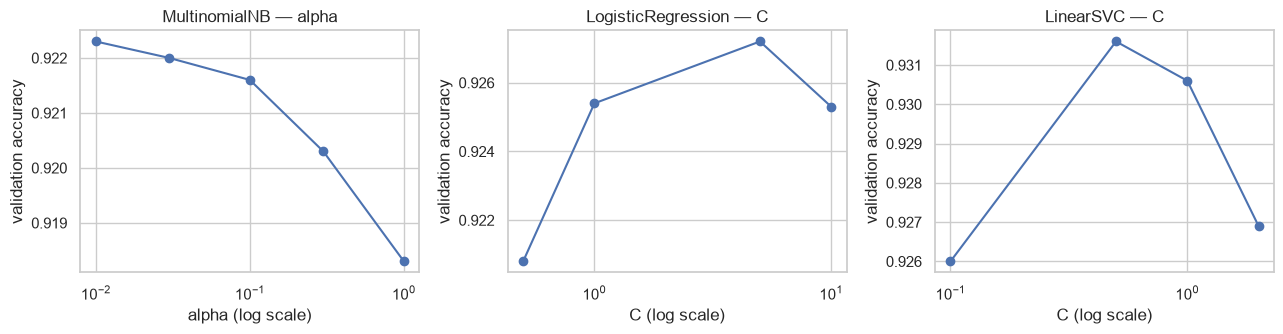

In [13]:
# Validation-accuracy curves for each swept hyperparameter (log-scaled x-axes).
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

axes[0].plot(nb_df["alpha"], nb_df["val_accuracy"], "o-")
axes[0].set_xscale("log")
axes[0].set_title("MultinomialNB — alpha")
axes[0].set_xlabel("alpha (log scale)")
axes[0].set_ylabel("validation accuracy")

axes[1].plot(lr_df["C"], lr_df["val_accuracy"], "o-")
axes[1].set_xscale("log")
axes[1].set_title("LogisticRegression — C")
axes[1].set_xlabel("C (log scale)")
axes[1].set_ylabel("validation accuracy")

axes[2].plot(svc_df["C"], svc_df["val_accuracy"], "o-")
axes[2].set_xscale("log")
axes[2].set_title("LinearSVC — C")
axes[2].set_xlabel("C (log scale)")
axes[2].set_ylabel("validation accuracy")

plt.tight_layout()
plt.show()

**Hyperparameter Tuning Results.**

- **N-gram range:** Combining unigrams and bigrams improves validation accuracy compared
  with using unigrams alone. Adding trigrams increases the number of features without
  producing a meaningful improvement, so unigrams and bigrams are selected.

- **Naive Bayes α:** The highest validation accuracy is obtained with `α = 0.01`.
  Performance gradually decreases as α increases, indicating that less smoothing works
  better for this dataset.

- **Regularization C:** Logistic Regression achieves its highest validation accuracy at
  `C = 5.0`, while Linear SVM performs best at `C = 0.5`. These values are therefore
  selected for the final models.

<a id="final-eval"></a>
## 6. Final evaluation on the test set

Each algorithm is retrained on the **full training set** using the best hyperparameters
found on the validation split, then evaluated **once** on the official 7,600-document test
set. We report accuracy, macro-F1, a per-model comparison chart, confusion matrices, and a
detailed per-class report for the best model.

*[back to top](#toc)*

In [14]:
# Retrain each model on the FULL training set with its best validation hyperparameters,
# then evaluate once on the held-out test set.
final_models = {
    "MultinomialNB":      MultinomialNB(alpha=best_alpha),
    "LogisticRegression": LogisticRegression(C=best_C_lr, max_iter=1000, solver="lbfgs"),
    "LinearSVC":          LinearSVC(C=best_C_svc, random_state=RANDOM_STATE),
}
final_results = [evaluate(m, n) for n, m in final_models.items()]

# Collect the scores into a tidy, sorted summary table.
summary = pd.DataFrame(
    [{k: r[k] for k in ("model", "accuracy", "macro_f1", "fit_seconds")} for r in final_results]
).sort_values("accuracy", ascending=False).reset_index(drop=True)
summary

MultinomialNB          accuracy=0.9136  macro-F1=0.9132  fit=0.0s


LogisticRegression     accuracy=0.9243  macro-F1=0.9242  fit=10.4s


LinearSVC              accuracy=0.9280  macro-F1=0.9279  fit=1.8s


,model,accuracy,macro_f1,fit_seconds
0,LinearSVC,0.928026,0.927862,1.8
1,LogisticRegression,0.924342,0.924195,10.4
2,MultinomialNB,0.913553,0.913233,0.0


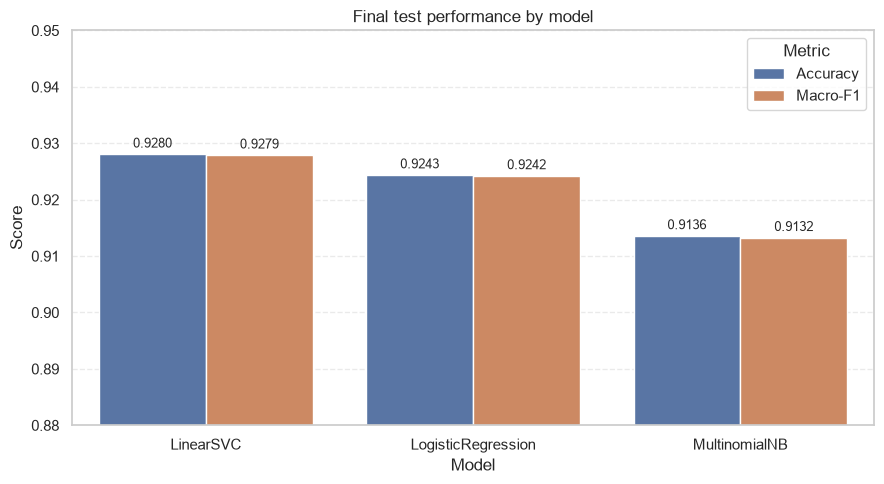

In [15]:
# Accuracy and macro-F1 comparison across the three tuned models.
# Reshape to long format so accuracy and macro-F1 become grouped bars per model.
plot_df = summary.melt(
    id_vars="model",
    value_vars=["accuracy", "macro_f1"],
    var_name="metric",
    value_name="score",
)
plot_df["metric"] = plot_df["metric"].map({"accuracy": "Accuracy", "macro_f1": "Macro-F1"})

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=plot_df, x="model", y="score", hue="metric")
ax.set_title("Final test performance by model")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0.88, 0.95)                       # zoom in so small differences are visible
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(title="Metric")

# Annotate each bar with its exact value.
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()

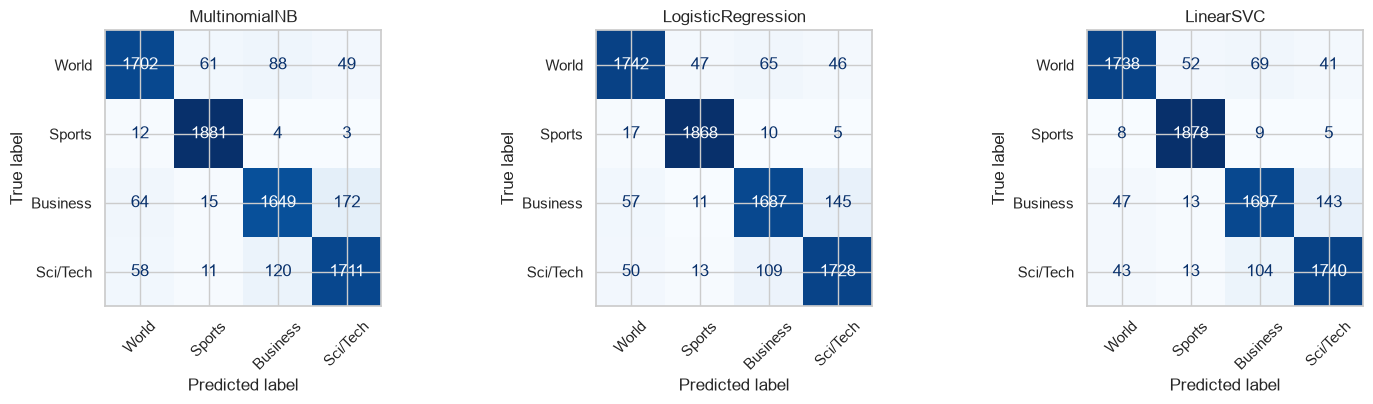

In [16]:
# Confusion matrices for all three models (rows = true class, columns = predicted).
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
labels_sorted = [CLASS_NAMES[i] for i in sorted(CLASS_NAMES)]
for ax, r in zip(axes, final_results):
    ConfusionMatrixDisplay.from_predictions(
        y_test, r["pred"], display_labels=labels_sorted, ax=ax,
        colorbar=False, cmap="Blues", xticks_rotation=45)
    ax.set_title(r["model"])
plt.tight_layout()
plt.show()

In [17]:
# Detailed per-class precision / recall / F1 for the best-performing model.
best = max(final_results, key=lambda r: r["accuracy"])
print("Best model:", best["model"])
print(classification_report(y_test, best["pred"], target_names=labels_sorted, digits=4))

Best model: LinearSVC
              precision    recall  f1-score   support

       World     0.9466    0.9147    0.9304      1900
      Sports     0.9601    0.9884    0.9741      1900
    Business     0.9031    0.8932    0.8981      1900
    Sci/Tech     0.9020    0.9158    0.9089      1900

    accuracy                         0.9280      7600
   macro avg     0.9280    0.9280    0.9279      7600
weighted avg     0.9280    0.9280    0.9279      7600



<a id="discussion"></a>
## 7. Discussion of results

**Results summary.** After tuning, the ranking from the baselines is preserved:
**Linear SVM is the best model (~92.8% accuracy / 0.928 macro-F1)**, Logistic Regression
is a close second (~92.4%), and Multinomial Naive Bayes reaches ~91.4% at a tiny fraction
of the training cost. Because the classes are perfectly balanced, accuracy and macro-F1
track each other almost exactly.

- **All three classical algorithms exceed 91% accuracy** on this balanced 4-class task,
  confirming that AG News is largely linearly separable in TF-IDF space. Linear SVM is the
  strongest, consistent with its usual advantage on high-dimensional sparse text features;
  Logistic Regression follows closely, and Naive Bayes — orders of magnitude faster to
  train — trails by only ~1.5 points.
- **Parameter sensitivity.** Adding bigrams over unigrams yields a consistent gain, while
  trigrams add features but little accuracy. Naive Bayes benefits noticeably from lowering
  α below the default 1.0. The linear models are fairly flat in C around their optimum,
  indicating a stable optimization landscape.
- **Error structure.** The confusion matrices show the dominant confusion is
  **Business ↔ Sci/Tech** (shared vocabulary about companies, markets and technology
  firms), while **Sports is nearly perfectly separated**. This mirrors the error structure
  reported for this benchmark by Zhang et al. (2015).
- **Context.** The character-level CNNs of Zhang et al. (2015) reach ~90–92% on this
  benchmark, i.e. carefully tuned classical linear models remain competitive with early
  deep models at a tiny fraction of the compute — a relevant efficiency observation for a
  big-data setting.
- **Limitations / future work.** Bag-of-words discards word order; a natural extension is a
  fine-tuned transformer (e.g. DistilBERT reaches ~94–95% on AG News), trading substantial
  compute for a modest accuracy gain.

*[back to top](#toc)*

<a id="conclusion"></a>
## 8. Conclusion

This project delivered a complete, self-contained pipeline for four-way topic
classification of the 127,600-article AG News corpus, comparing three classical machine-
learning algorithms under a leakage-safe protocol (tuning on a validation split, a single
final test evaluation).

**Key takeaways:**

- **A tuned Linear SVM over sublinear TF-IDF (unigrams + bigrams) is the best model**,
  reaching ~92.8% test accuracy / 0.928 macro-F1; Logistic Regression is within half a
  point, and Naive Bayes is only ~1.5 points behind while being by far the cheapest to
  train.
- **The task is largely linearly separable**: the well-separated per-class vocabularies
  seen in the EDA translate directly into strong linear-model performance, and the residual
  errors are concentrated in the semantically overlapping *Business ↔ Sci/Tech* pair.
- **Hyperparameter tuning matters but is not fragile**: bigrams and a low Naive Bayes α give
  real gains, while the linear models are robust to the exact choice of C.
- **Classical models remain competitive**: these results are on par with the early
  character-level CNN benchmark at a tiny fraction of the compute — a meaningful efficiency
  point for big-data settings.

All course size requirements are satisfied (N = 127,600; p ≈ 200,000; 3 algorithms;
N·p ≈ 2.5 × 10¹⁰), the notebook downloads its own data and runs end-to-end without manual
steps, and the natural next step for higher accuracy would be a fine-tuned transformer.

*[back to top](#toc)*

<a id="references"></a>
## References

1. **Zhang, X., Zhao, J., & LeCun, Y. (2015).** *Character-level Convolutional Networks for
   Text Classification.* Advances in Neural Information Processing Systems (NeurIPS) 28.
   — Introduces the AG News classification benchmark used here.
   https://arxiv.org/abs/1509.01626
2. **AG News dataset (HuggingFace mirror, `sh0416/ag_news`).**
   https://huggingface.co/datasets/sh0416/ag_news — primary data source for this notebook.
   Original news corpus compiled by ComeToMyHead; benchmark split popularized by Zhang et al.
3. **GitHub CSV mirror of AG News** (used as the automatic download fallback).
   https://github.com/mhjabreel/CharCnn_Keras/tree/master/data/ag_news_csv
4. **Pedregosa, F., et al. (2011).** *Scikit-learn: Machine Learning in Python.* Journal of
   Machine Learning Research, 12, 2825–2830. — Implementation of TF-IDF, Multinomial Naive
   Bayes, Logistic Regression and `LinearSVC`. https://scikit-learn.org
5. **Manning, C. D., Raghavan, P., & Schütze, H. (2008).** *Introduction to Information
   Retrieval.* Cambridge University Press. — Reference for TF-IDF weighting and text
   classification with Naive Bayes and linear models.

*[back to top](#toc)*